# Seasonal Agriculture Performance Analysis


## Project Overview

This project analyzes agricultural activities across different seasons,
regions, crops, farming practices, environmental conditions, resource usage,
and economic outcomes.

The objective is to identify meaningful seasonal patterns, differences,
relationships, and variations in agricultural performance using data
analytics and visualization techniques.

## Key Areas of Analysis

- Seasonal agricultural performance
- Crop-wise performance
- Regional differences
- Environmental conditions
- Resource utilization
- Yield and production
- Water efficiency
- Revenue, cost and profit
- Disease and pest risk
- Relationships between agricultural variables
- Statistical differences between seasons
- Unusual patterns and outliers


## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


##Upload the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


##Load the dataset

In [ ]:
file_name = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_name)
print("Dataset loaded successfully!")

Dataset loaded successfully!


##Display first 5 rows

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


##Number of rows and columns

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


##Dataset information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

##Column names

In [ ]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Columns in the dataset:

1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


##Statistical Summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


##Check Data types

In [ ]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


##Numerical columns

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


##Categorical columns

In [ ]:
categorical_columns = df.select_dtypes(include='object').columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


##Missing value analysis


In [ ]:
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[
    missing_values['Missing Values'] > 0
].sort_values(
    by='Missing Values',
    ascending=False
)

missing_values

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


##Visualize missing values

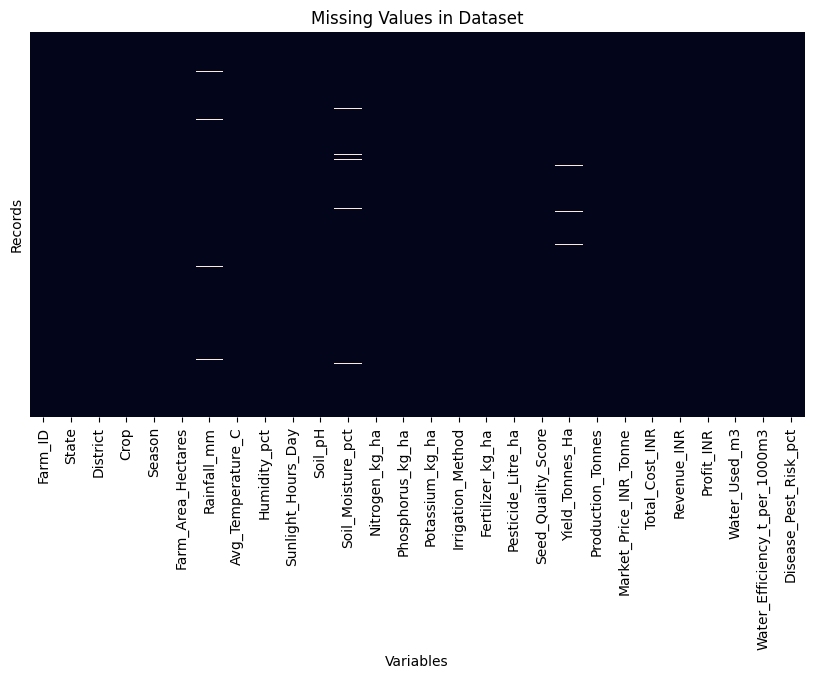

In [ ]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in Dataset")
plt.xlabel("Variables")
plt.ylabel("Records")

plt.show()

##Duplicate record analysis

In [ ]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


##Unique values

In [ ]:
for column in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print("\n", column)
    print("Number of unique values:", df[column].nunique())
    print(df[column].unique())


 State
Number of unique values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

 District
Number of unique values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

 Crop
Number of unique values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

 Season
Number of unique values: 3
['Kharif' 'Rabi' 'Zaid']

 Irrigation_Method
Number of unique values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


##Handle missing values

In [ ]:
# Fill missing rainfall with median rainfall
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df['Rainfall_mm'].median()
)

# Fill missing soil moisture with median soil moisture
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

# Fill missing yield with median yield
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

print("Missing numerical values handled successfully.")

Missing numerical values handled successfully.


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


##Basic Data validation

In [ ]:
checks = {
    'Farm Area <= 0': (df['Farm_Area_Hectares'] <= 0).sum(),
    'Yield < 0': (df['Yield_Tonnes_Ha'] < 0).sum(),
    'Production < 0': (df['Production_Tonnes'] < 0).sum(),
    'Revenue < 0': (df['Revenue_INR'] < 0).sum(),
    'Water Used < 0': (df['Water_Used_m3'] < 0).sum(),
    'Soil pH outside 0-14': (
        (df['Soil_pH'] < 0) | (df['Soil_pH'] > 14)
    ).sum()
}

for check, count in checks.items():
    print(f"{check}: {count}")

Farm Area <= 0: 0
Yield < 0: 0
Production < 0: 0
Revenue < 0: 0
Water Used < 0: 0
Soil pH outside 0-14: 0


##Profit Margin

In [ ]:
df['Profit_Margin_pct'] = (
    df['Profit_INR'] / df['Revenue_INR']
) * 100

##Cost per hectare

In [ ]:
df['Cost_per_Hectare'] = (
    df['Total_Cost_INR'] / df['Farm_Area_Hectares']
)

##Revenue per hectare

In [ ]:
df['Revenue_per_Hectare'] = (
    df['Revenue_INR'] / df['Farm_Area_Hectares']
)

##Profit per hectare

In [ ]:
df['Profit_per_Hectare'] = (
    df['Profit_INR'] / df['Farm_Area_Hectares']
)

In [ ]:
df[
    [
        'Profit_Margin_pct',
        'Cost_per_Hectare',
        'Revenue_per_Hectare',
        'Profit_per_Hectare'
    ]
].head()

,Profit_Margin_pct,Cost_per_Hectare,Revenue_per_Hectare,Profit_per_Hectare
0,-38.468030,80494.339623,58132.075472,-22362.264151
1,-1118.660429,75398.315467,6186.983155,-69211.332312
2,-65.494104,64858.024691,39190.534979,-25667.489712
3,-47.675600,65876.444444,44608.888889,-21267.555556
4,-74.559288,80275.296912,45987.410926,-34287.885986


# 1. Seasonal Agricultural Performance

The first stage of analysis examines whether agricultural performance
differs across Kharif, Rabi and Zaid seasons.

The analysis considers yield, production, revenue, cost, profit,
water usage and disease/pest risk.

##Number of farms per season

In [ ]:
season_counts = df['Season'].value_counts()
season_counts

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


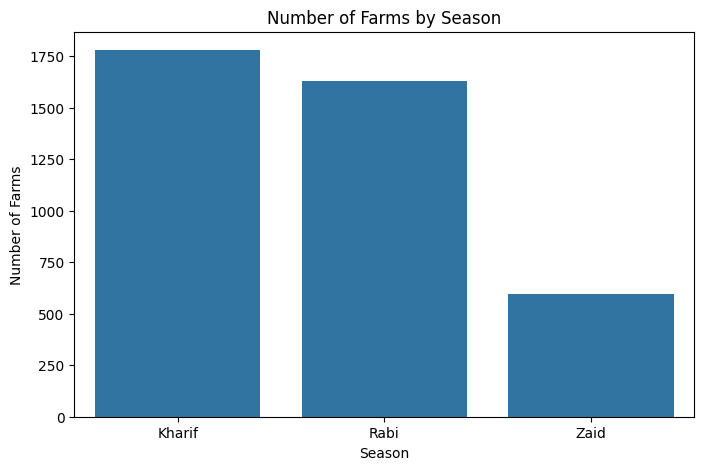

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Season',
    order=df['Season'].value_counts().index
)

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.show()

##Average agricultural performance by season

In [ ]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


##Seasonal yield comparison

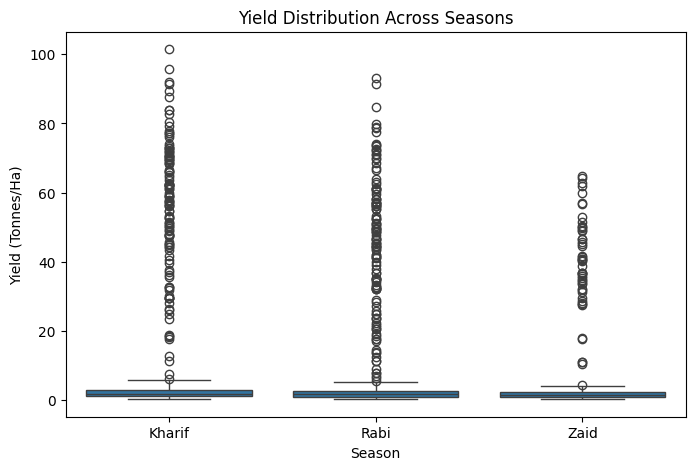

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

##Average yield by season

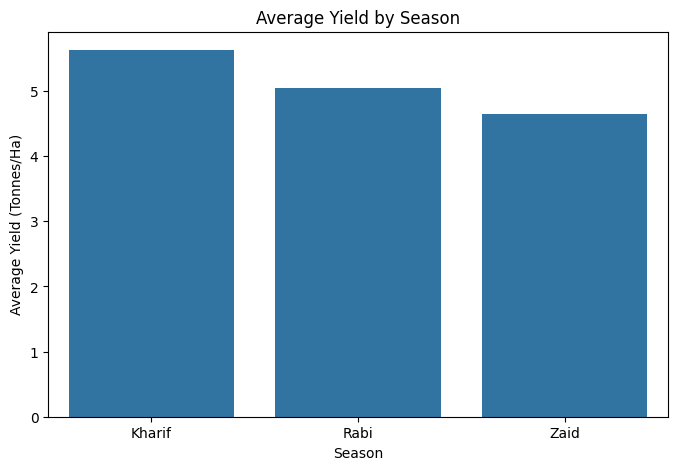

In [ ]:
season_yield = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.show()

##Profit by season

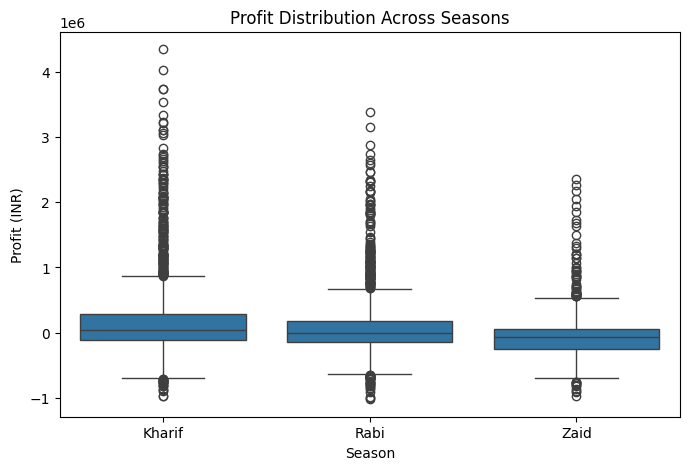

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.show()

##Average profit by season

In [ ]:
season_profit = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

season_profit

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


##Economic performance

In [ ]:
economic_summary = df.groupby('Season').agg({
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Profit_Margin_pct': 'mean'
}).round(2)

economic_summary

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,710719.06,531804.41,178914.65,-38.64
Rabi,601526.05,513836.58,87689.47,-44.27
Zaid,519171.90,543976.73,-24804.82,-69.35


##Revenue vs cost vs profit

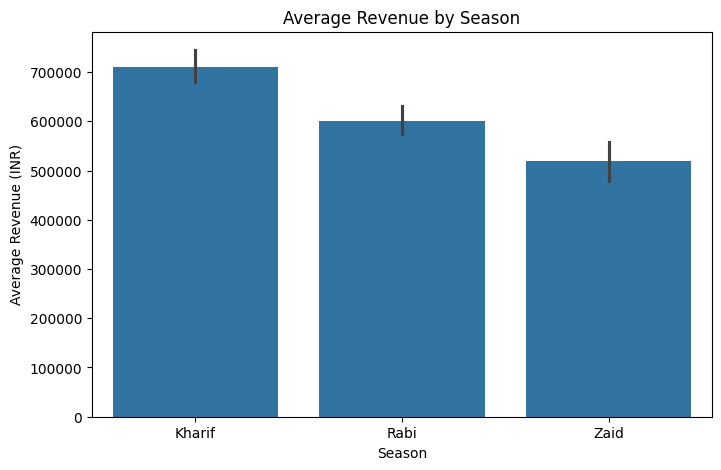

In [ ]:
#Revenue
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Revenue_INR',
    estimator='mean'
)

plt.title("Average Revenue by Season")
plt.ylabel("Average Revenue (INR)")
plt.xlabel("Season")

plt.show()

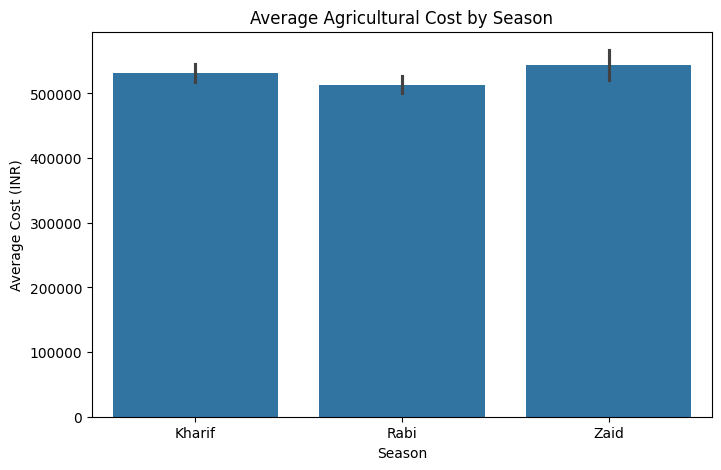

In [ ]:
#Cost
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Total_Cost_INR',
    estimator='mean'
)

plt.title("Average Agricultural Cost by Season")
plt.ylabel("Average Cost (INR)")
plt.xlabel("Season")

plt.show()

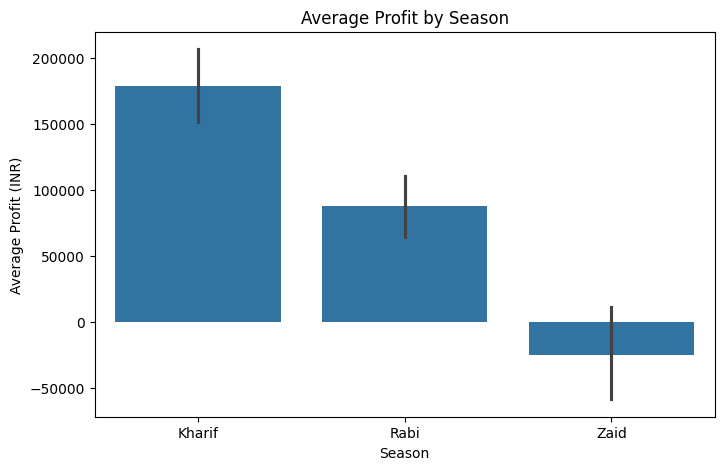

In [ ]:
#Profit
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean'
)

plt.title("Average Profit by Season")
plt.ylabel("Average Profit (INR)")
plt.xlabel("Season")

plt.show()

##Water usage by seasons

In [ ]:
water_summary = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

water_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


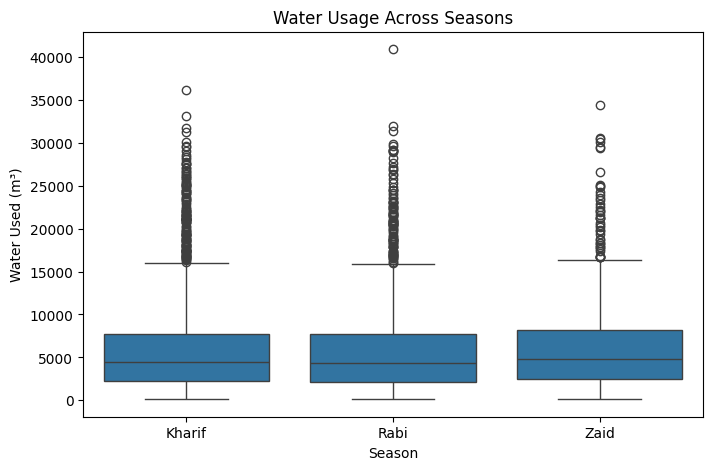

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Water_Used_m3'
)

plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.show()

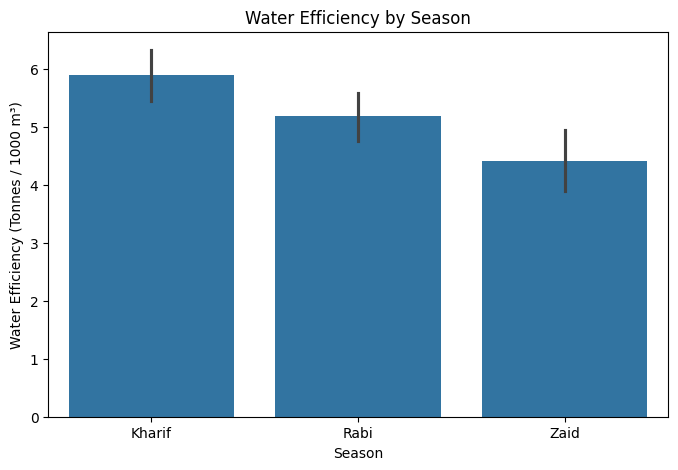

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    estimator='mean'
)

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes / 1000 m³)")

plt.show()

##Environmental conditions by season

In [ ]:
environment_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
}).round(2)

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


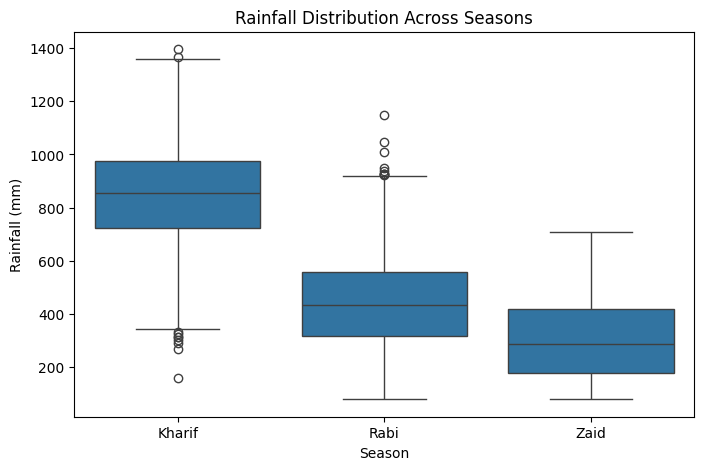

In [ ]:
#Rainfall
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Rainfall_mm'
)

plt.title("Rainfall Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.show()

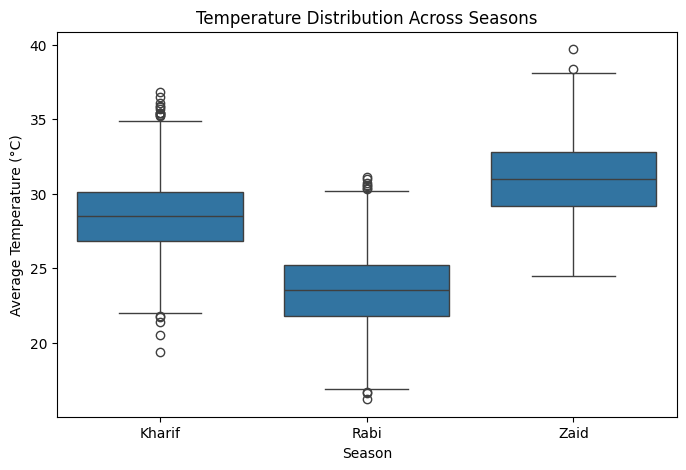

In [ ]:
#Temperature
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title("Temperature Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")

plt.show()

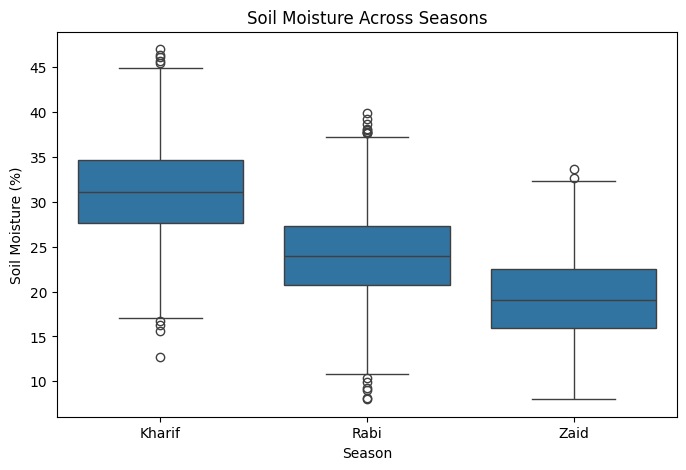

In [ ]:
#Soil moisture
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Soil_Moisture_pct'
)

plt.title("Soil Moisture Across Seasons")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")

plt.show()

##Crop wise seasonal analysis

In [ ]:
crop_season_yield = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


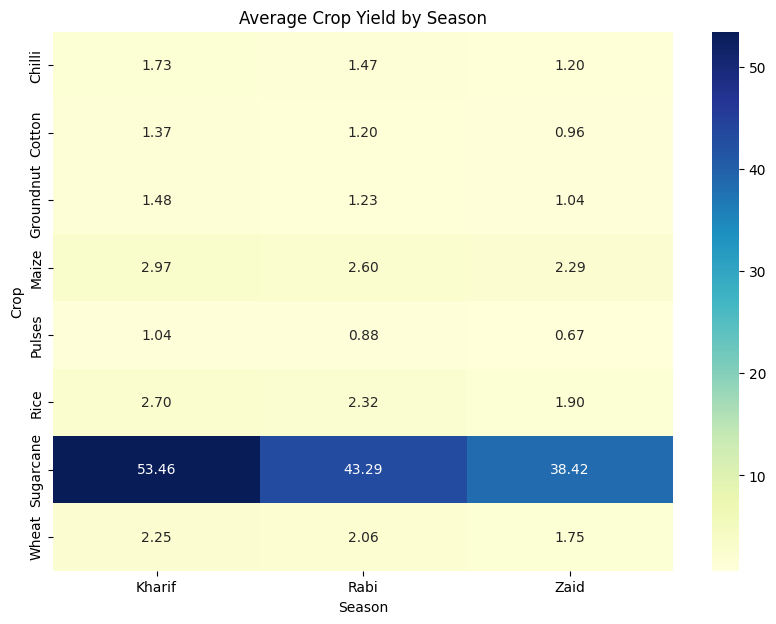

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

##Crop profitability

In [ ]:
crop_profit = (
    df.groupby('Crop')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

crop_profit

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


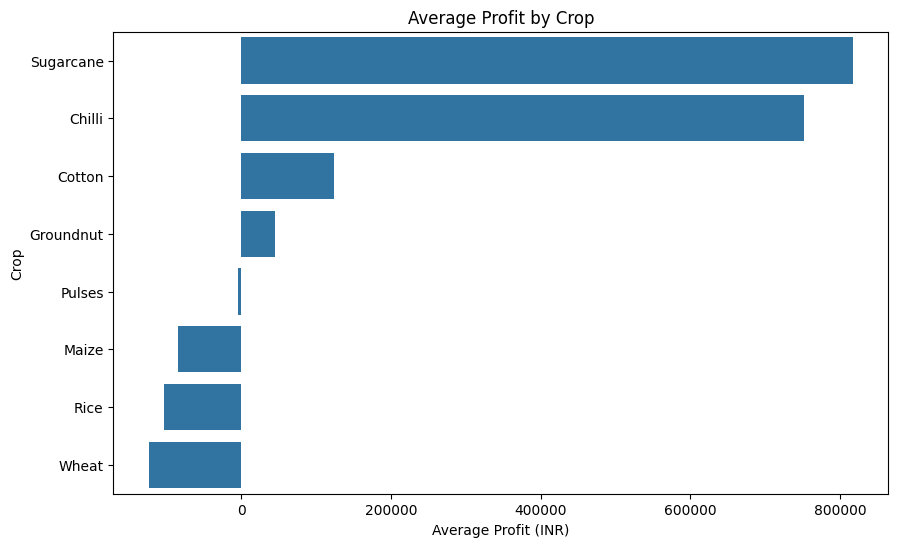

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_profit.values,
    y=crop_profit.index
)

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")

plt.show()

##State-wise agricultural performance

In [ ]:
state_summary = df.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

state_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
State,,,,,,
Andhra Pradesh,4.63,36.91,606663.66,73453.53,5.03,46.72
Gujarat,5.66,48.33,654692.86,117568.24,5.58,45.95
Karnataka,5.69,47.73,653426.18,119422.34,5.56,46.06
Madhya Pradesh,4.99,37.56,597558.36,86840.76,5.27,47.08
Maharashtra,5.02,43.98,650032.67,135428.86,5.28,46.44
Punjab,6.12,52.23,686225.70,136025.64,5.62,46.00
Tamil Nadu,4.88,40.84,629093.42,117744.75,5.31,46.28
Telangana,5.04,39.25,628784.53,108829.62,5.46,46.36


##State vs season

In [ ]:
state_season_profit = pd.pivot_table(
    df,
    values='Profit_INR',
    index='State',
    columns='Season',
    aggfunc='mean'
)

state_season_profit.round(2)

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


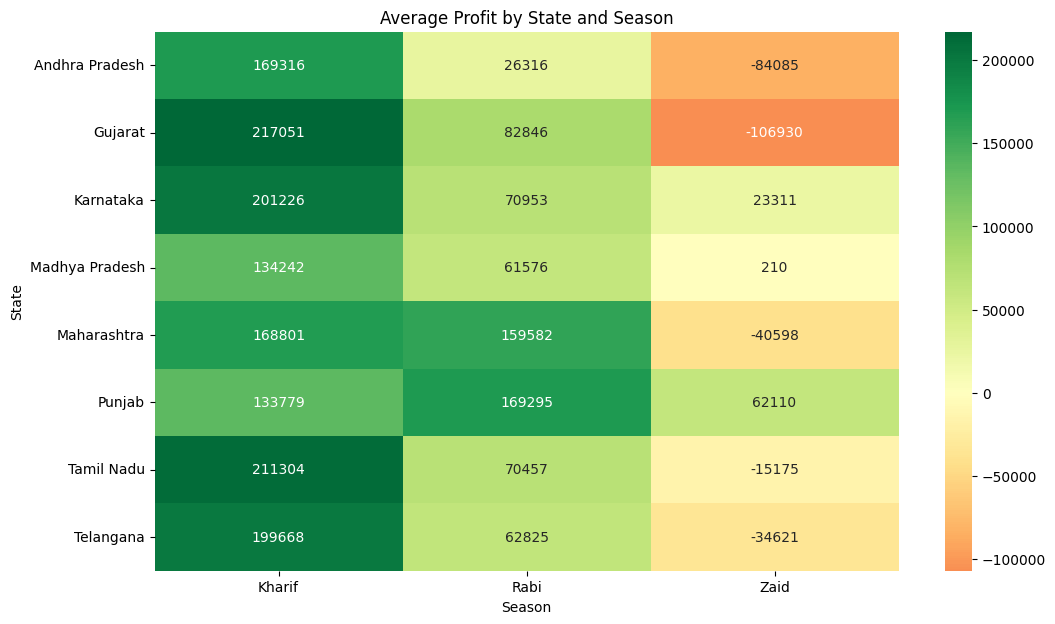

In [ ]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    state_season_profit,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0
)

plt.title("Average Profit by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.show()

##Irrigation method analysis

In [ ]:
irrigation_summary = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Profit_INR': 'mean'
}).round(2)

irrigation_summary

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.58,5918.75,6.27,219626.00
Flood,4.86,8026.47,3.44,73354.02
Rainfed,4.60,3549.55,7.56,79050.37
Sprinkler,5.16,6208.26,4.67,91121.08


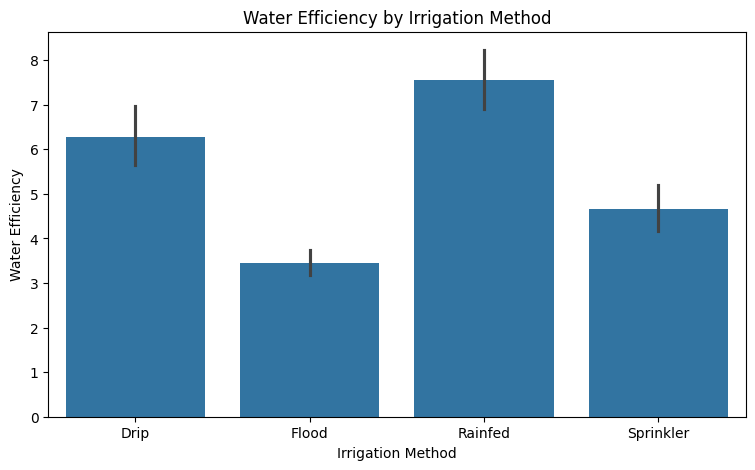

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Water_Efficiency_t_per_1000m3',
    estimator='mean'
)

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency")

plt.show()

##Correlation analysis

In [ ]:
correlation_columns = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation_matrix = df[correlation_columns].corr()

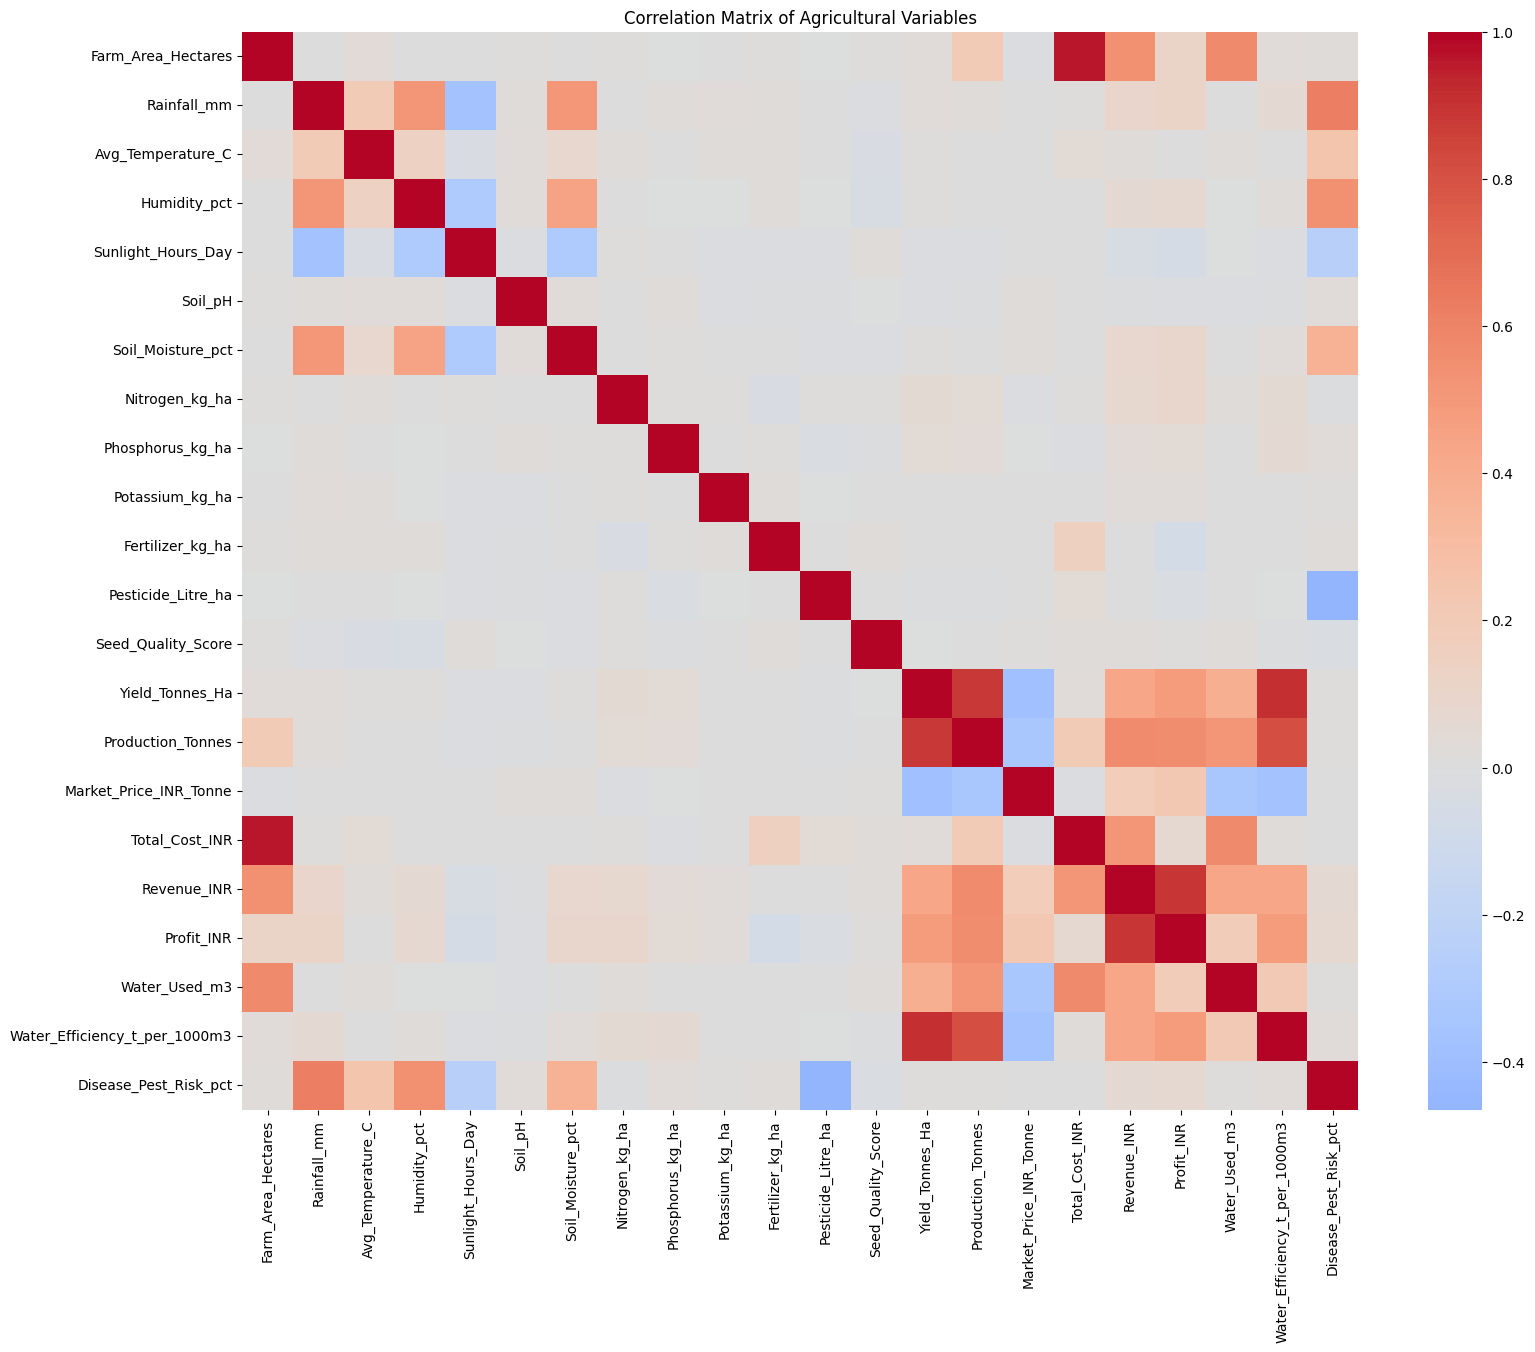

In [ ]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.show()

##Focused correlation with yield

In [ ]:
yield_correlations = (
    correlation_matrix['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

yield_correlations

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [ ]:
profit_correlations = (
    correlation_matrix['Profit_INR']
    .sort_values(ascending=False)
)

profit_correlations

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.488466
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.107648
Soil_Moisture_pct,0.091281


##Seasonal correlation

In [ ]:
for season in df['Season'].unique():

    season_data = df[df['Season'] == season]

    corr = season_data[correlation_columns].corr()

    print("\n======================================")
    print(f"Correlation Analysis — {season}")
    print("======================================")

    print(
        corr['Yield_Tonnes_Ha']
        .sort_values(ascending=False)
        .head(10)
    )


Correlation Analysis — Kharif
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915788
Production_Tonnes                0.885087
Profit_INR                       0.466722
Revenue_INR                      0.412706
Water_Used_m3                    0.356803
Phosphorus_kg_ha                 0.050772
Nitrogen_kg_ha                   0.047718
Farm_Area_Hectares               0.025753
Total_Cost_INR                   0.023670
Name: Yield_Tonnes_Ha, dtype: float64

Correlation Analysis — Rabi
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.904675
Production_Tonnes                0.885840
Profit_INR                       0.514707
Revenue_INR                      0.451222
Water_Used_m3                    0.422873
Nitrogen_kg_ha                   0.072858
Avg_Temperature_C                0.054888
Rainfall_mm                      0.044218
Phosphorus_kg_ha                 0.040749
Name: Yield_Tonnes_Ha, dtype: float64

Correlation Analysis — 

## ANOVA TEST — YIELD ACROSS SEASONS

In [ ]:
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

anova_result = stats.f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [ ]:
alpha = 0.05

if anova_result.pvalue < alpha:
    print(
        "Result: There is a statistically significant difference "
        "in yield among the seasons."
    )
else:
    print(
        "Result: No statistically significant difference "
        "in yield among the seasons was detected."
    )

Result: No statistically significant difference in yield among the seasons was detected.


## ANOVA for profit

In [ ]:
kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR']
rabi_profit = df[df['Season'] == 'Rabi']['Profit_INR']
zaid_profit = df[df['Season'] == 'Zaid']['Profit_INR']

profit_anova = stats.f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("F-statistic:", profit_anova.statistic)
print("P-value:", profit_anova.pvalue)

F-statistic: 34.29175033935195
P-value: 1.7124156677360182e-15


###Interpretation

In [ ]:
if profit_anova.pvalue < 0.05:
    print("Profit differs significantly across seasons.")
else:
    print("No statistically significant seasonal difference in profit.")

Profit differs significantly across seasons.


##Disease and pest risk

In [ ]:
disease_summary = df.groupby('Season')['Disease_Pest_Risk_pct'].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

disease_summary

,mean,median,min,max
Season,,,,
Kharif,54.47,54.5,21.3,88.9
Rabi,40.48,40.6,5.1,71.2
Zaid,38.22,37.9,5.0,71.6


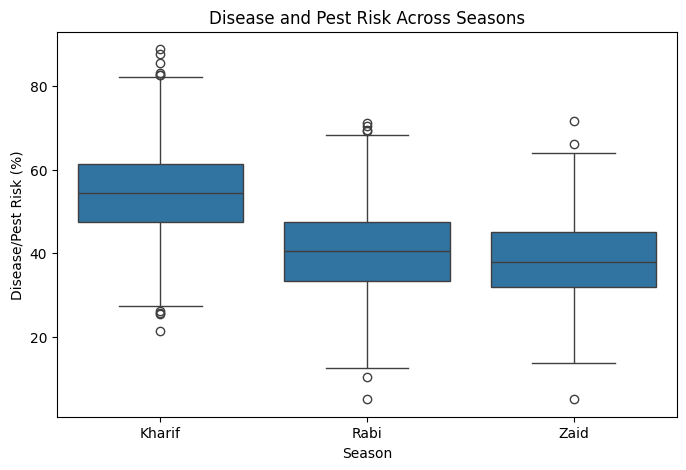

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title("Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")

plt.show()

##Identify unusual yield values

In [ ]:
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = df[
    (df['Yield_Tonnes_Ha'] < lower_bound) |
    (df['Yield_Tonnes_Ha'] > upper_bound)
]

print("Number of yield outliers:", len(yield_outliers))

Number of yield outliers: 302


In [ ]:
yield_outliers[
    [
        'Farm_ID',
        'State',
        'District',
        'Crop',
        'Season',
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Profit_INR'
    ]
].head(20)

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
47,SF10048,Punjab,Ludhiana,Sugarcane,Zaid,36.69,281.78,556688
75,SF10076,Maharashtra,Guntur,Sugarcane,Kharif,62.58,665.85,1675730
79,SF10080,Karnataka,Nashik,Sugarcane,Zaid,33.55,311.68,691166
82,SF10083,Andhra Pradesh,Raichur,Sugarcane,Rabi,49.52,121.82,279221
92,SF10093,Gujarat,Guntur,Sugarcane,Kharif,70.23,894.73,2427692
113,SF10114,Tamil Nadu,Rajkot,Sugarcane,Rabi,58.06,833.16,2324331
132,SF10133,Telangana,Warangal,Sugarcane,Kharif,29.47,112.87,89113
154,SF10155,Telangana,Ludhiana,Sugarcane,Kharif,47.88,436.67,798280
155,SF10156,Madhya Pradesh,Guntur,Sugarcane,Kharif,62.09,279.41,573019
164,SF10165,Telangana,Guntur,Sugarcane,Rabi,36.91,147.64,297233


##Distribution of yield

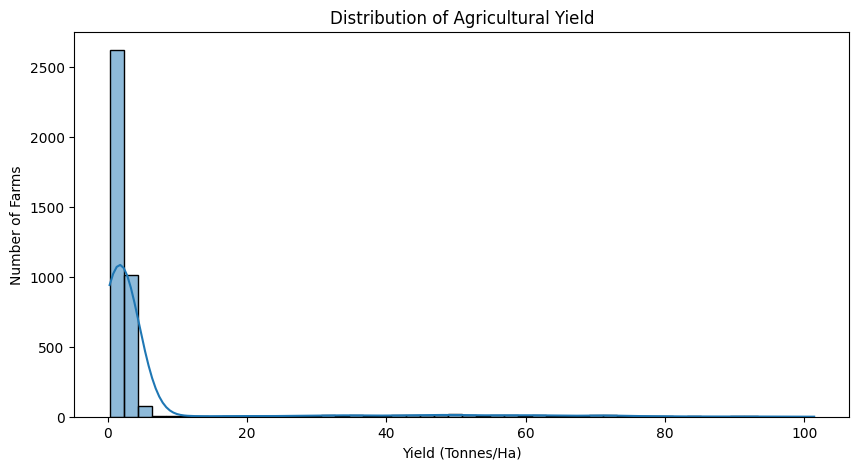

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Yield_Tonnes_Ha',
    bins=50,
    kde=True
)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Number of Farms")

plt.show()

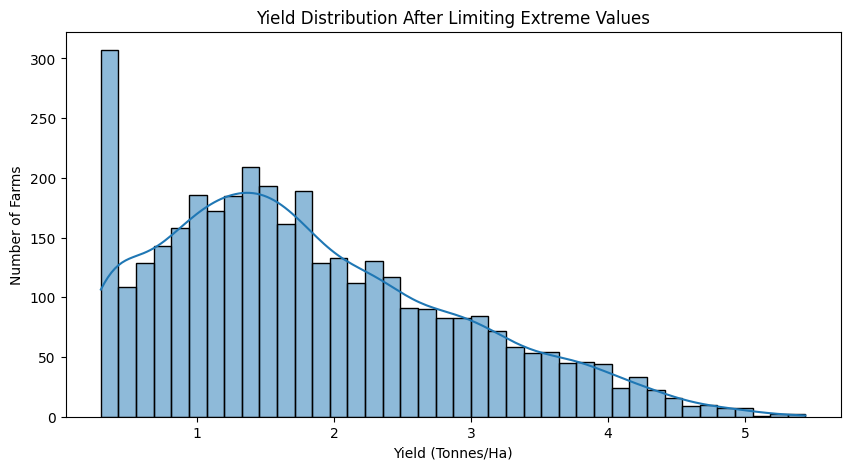

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df[df['Yield_Tonnes_Ha'] <= upper_bound]['Yield_Tonnes_Ha'],
    bins=40,
    kde=True
)

plt.title("Yield Distribution After Limiting Extreme Values")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Number of Farms")

plt.show()

##Final seasonal scorecard

In [70]:
final_season_scorecard = df.groupby('Season').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2)

final_season_scorecard

,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,1627,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


##Automatically identify best-performing season

In [71]:
best_yield_season = (
    final_season_scorecard['Avg_Yield']
    .idxmax()
)

best_profit_season = (
    final_season_scorecard['Avg_Profit']
    .idxmax()
)

best_water_efficiency_season = (
    final_season_scorecard['Avg_Water_Efficiency']
    .idxmax()
)

lowest_disease_risk_season = (
    final_season_scorecard['Avg_Disease_Risk']
    .idxmin()
)

print("Highest average yield:", best_yield_season)
print("Highest average profit:", best_profit_season)
print("Highest water efficiency:", best_water_efficiency_season)
print("Lowest disease/pest risk:", lowest_disease_risk_season)

Highest average yield: Kharif
Highest average profit: Kharif
Highest water efficiency: Kharif
Lowest disease/pest risk: Zaid


# Final Findings and Conclusions

## Key Findings

Based on the analysis of 4,000 agricultural records, the following key findings were identified:

1. **Kharif showed the highest average yield**, at approximately **5.63 tonnes/hectare**, followed by Rabi at 5.04 tonnes/hectare and Zaid at 4.64 tonnes/hectare.

2. **Kharif recorded the highest average production**, revenue and profit. Its average profit was approximately **₹178,915**, compared with ₹87,689 for Rabi and an average loss of approximately ₹24,805 for Zaid.

3. The **ANOVA test for yield** produced an F-statistic of **1.54** and a p-value of **0.214**. Since the p-value is greater than 0.05, the analysis did **not detect a statistically significant difference in average yield across seasons**.

4. In contrast, the **ANOVA test for profit** produced an F-statistic of **34.29** and a p-value below **0.001**, indicating that **profit differs significantly across seasons**.

5. **Water usage varied across seasons.** Zaid had the highest average water usage at approximately **6,419.89 m³**, while Rabi had the lowest at approximately **5,846.99 m³**.

6. **Kharif had the highest average water efficiency**, at approximately **5.89 tonnes per 1,000 m³**, while Zaid had the lowest at approximately 4.41 tonnes per 1,000 m³.

7. **Disease and pest risk was highest in Kharif**, at approximately **54.47%**, while Zaid had the lowest average risk at approximately **38.22%**.

8. Environmental conditions including rainfall, temperature, humidity, sunlight and soil moisture showed clear differences between seasons.

9. Crop-wise and regional comparisons showed that agricultural performance can vary across crops, states and seasons rather than following one uniform pattern.

10. Correlation analysis was used to investigate relationships between environmental/resource variables and agricultural outcomes, while outlier analysis identified unusual observations requiring further investigation.

Overall, the analysis indicates that **seasonal differences are particularly important for economic performance and resource efficiency**, even though the observed differences in average yield were not statistically significant.


# Recommendations

Based on the findings from the analysis, the following data-driven recommendations can be considered:

### 1. Seasonal Planning

Agricultural planning should consider seasonal differences in profitability, water requirements, environmental conditions and disease/pest risk. Kharif showed the strongest overall economic performance in the analyzed dataset.

### 2. Improve Water Management

Zaid recorded the highest average water usage but the lowest water efficiency. Water management and irrigation practices during Zaid should therefore be investigated to identify opportunities for reducing water consumption and improving productivity.

### 3. Use Crop-Specific Strategies

Crop selection and farming practices should consider the season in which individual crops perform better. Crop-wise seasonal comparisons can help farmers select combinations with stronger yield and economic performance.

### 4. Consider Regional Differences

State and district-level performance should be considered when making agricultural decisions because seasonal patterns may differ across geographical areas.

### 5. Manage Disease and Pest Risk

Kharif showed the highest average disease and pest risk. Additional monitoring and preventive measures may therefore be useful during higher-risk seasonal periods.

### 6. Focus on Profitability

Since the statistical analysis found a significant difference in profit across seasons, agricultural planning should evaluate profitability in addition to yield. Revenue, production costs and profit should be considered together when comparing seasonal performance.

### 7. Investigate Unusual Observations

The unusual yield observations identified through outlier analysis should be investigated further to determine whether they represent genuinely high-performing or low-performing agricultural activities or potential data-quality issues.

### 8. Evidence-Based Planning

Future agricultural decisions should combine historical yield, profitability, environmental conditions, water usage, irrigation practices and risk indicators rather than relying on a single performance measure.


# Conclusion

This project analyzed **4,000 agricultural records** to understand how agricultural performance varies across Kharif, Rabi and Zaid seasons.

The analysis showed that **Kharif had the highest average yield, production, revenue, profit and water efficiency** among the three seasons. However, the ANOVA test showed that the difference in average yield across seasons was not statistically significant. In contrast, the profit ANOVA indicated a statistically significant difference in profit between seasons.

The analysis also identified important differences in water usage, water efficiency and disease/pest risk. Zaid had the highest average water usage and lowest water efficiency, while Kharif had the highest average disease and pest risk.

Crop-wise, regional, environmental, irrigation and correlation analyses provided additional insight into the factors associated with agricultural performance. Outlier analysis also highlighted unusual observations that may require further investigation.

Overall, the findings demonstrate that **seasonal agricultural planning should consider profitability, resource efficiency, environmental conditions and agricultural risks together with yield**. These evidence-based insights can support better planning and more efficient use of agricultural resources.
